<a href="https://colab.research.google.com/github/CobraIvi11/CobraIvi11-Esercizio_RetiNeurali/blob/main/Viero_RandomForest_VinoQualit%C3%A0Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forests — Wine Quality Dataset
> **Autore:** Viero Ivan  
> **Obiettivo:** Classificare la qualità del vino usando alberi randomici  
> **Target accuracy:** 75%–85%

---

## Come funziona

```
X dataset
    ├── N₁ features → Albero 1 → Classe A
    ├── N₂ features → Albero 2 → Classe C
    ├── N₃ features → Albero 3 → Classe A
    └── N₄ features → Albero 4 → Classe A
                              ↓
                     MAJORITY VOTING
                              ↓
                       FINAL CLASS → A
```

Ogni albero vede **feature casuali**: questa scelta opta per ridurre la correlazione tra gli alberi e serve per combattere l'overfitting.

## 1. Installazione e Import

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('✅ Librerie importate correttamente')

✅ Librerie importate correttamente


## 2. Caricamento Dataset Wine Quality

In [ ]:
import io, requests
url_red   = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
url_white = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv'

df_red   = pd.read_csv(io.StringIO(requests.get(url_red).text),   sep=';')
df_white = pd.read_csv(io.StringIO(requests.get(url_white).text), sep=';')
df_all   = pd.concat([df_red, df_white], ignore_index=True)

X = df_all.drop(columns=['quality'])
y = df_all['quality']

print(f'Dataset caricato: {X.shape[0]} campioni, {X.shape[1]} features')
print(f'Features: {list(X.columns)}')
print(f'\nDistribuzione classi (qualità 0-10):')
print(y.value_counts().sort_index())

Dataset caricato: 6497 campioni, 11 features
Features: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Distribuzione classi (qualità 0-10):
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64


## 3. Preprocessing — Binarizzazione Target

Nel dataset si può trovare la qualità con i parametri che si aggirano tra i 3 ai 9. Per semplicità ho convertito in:
- **0 = Bassa qualità** (score ≤ 5)
- **1 = Alta qualità** (score ≥ 6)

Questo rende il problema binario e ben bilanciato.

Distribuzione target binario:
  Bassa qualità (0): 2384 campioni (36.7%)
  Alta qualità  (1): 4113 campioni (63.3%)


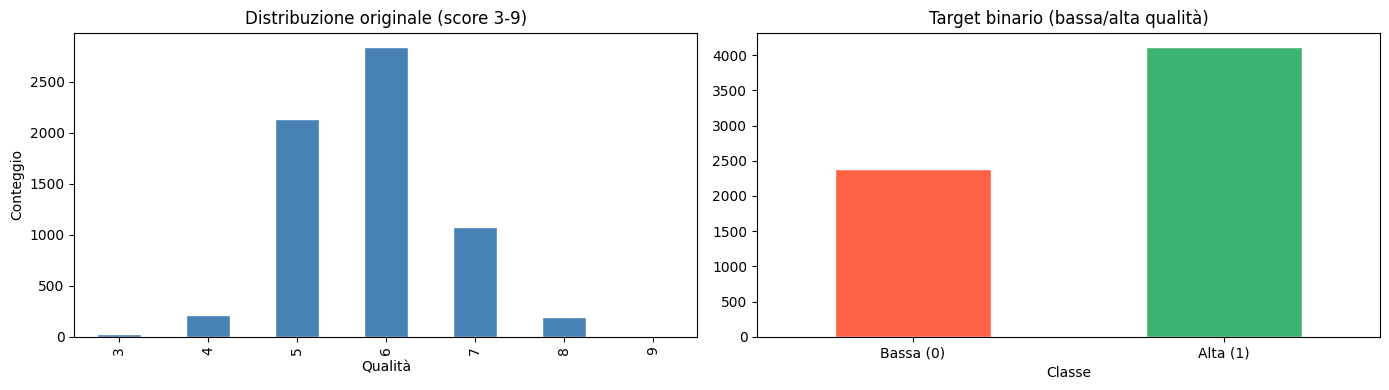

In [ ]:
y_bin = (y >= 6).astype(int)

print('Distribuzione target binario:')
counts = y_bin.value_counts()
print(f'  Bassa qualità (0): {counts[0]} campioni ({counts[0]/len(y_bin)*100:.1f}%)')
print(f'  Alta qualità  (1): {counts[1]} campioni ({counts[1]/len(y_bin)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

y.value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribuzione originale (score 3-9)', fontsize=12)
axes[0].set_xlabel('Qualità')
axes[0].set_ylabel('Conteggio')

y_bin.value_counts().sort_index().plot(kind='bar', ax=axes[1],
                                        color=['tomato', 'mediumseagreen'], edgecolor='white')
axes[1].set_title('Target binario (bassa/alta qualità)', fontsize=12)
axes[1].set_xlabel('Classe')
axes[1].set_xticklabels(['Bassa (0)', 'Alta (1)'], rotation=0)

plt.tight_layout()
plt.show()

## 4. Train/Test Split
Ho preferito dividere i risultati in:
- **70% (Training Set)** per far "studiare" il modello e fargli apprendere i pattern dai dati
- **30% (Test Set)** funge da esame finale su dati mai visti per misurarne l'accuratezza reale.
- **N.B.** La stratificazione garantisce che la proporzione tra le classi rimanga identica in entrambi i gruppi, evitando sbilanciamenti nei risultati.

In [ ]:
X_tr, X_ts, y_tr, y_ts = train_test_split(
    X, y_bin,
    test_size=0.30,
    random_state=42,
    stratify=y_bin
)

print(f'Training set:  {X_tr.shape[0]} campioni')
print(f'Test set:      {X_ts.shape[0]} campioni')

Training set:  4547 campioni
Test set:      1950 campioni


## 5. Random Forest — Alberi Piccoli
### Parametri chiave per controllare l'overfitting:

| Parametro | Valore | Effetto |
|-----------|--------|---------|
| `n_estimators` | 200 | Numero di alberi  |
| `max_depth` | 4 | **Alberi piccoli** → impedisce memorizzazione |
| `max_features` | 'sqrt' | Ogni albero vede √11 ≈ 3 feature casuali |
| `min_samples_leaf` | 10 | Foglie con almeno 10 campioni → no overfitting |
| `min_samples_split` | 20 | Nodo splitta solo se ha ≥20 campioni |
| `bootstrap` | True | Ogni albero su campione diverso (bagging)|

In [ ]:
clf = RandomForestClassifier(
    n_estimators=400,
    max_depth=7,
    max_features='sqrt',
    min_samples_leaf=10,
    min_samples_split=20,
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

clf.fit(X_tr, y_tr)

y_pred = clf.predict(X_ts)

acc_train = accuracy_score(y_tr, clf.predict(X_tr))
acc_test  = accuracy_score(y_ts, y_pred)
oob       = clf.oob_score_
gap       = acc_train - acc_test

print('RISULTATI RANDOM FOREST')
print(f'  Accuracy TRAIN:    {acc_train*100:.2f}%')
print(f'  Accuracy TEST:     {acc_test*100:.2f}%')
print(f'  OOB Score:         {oob*100:.2f}%')
print(f'  Gap train-test:    {gap*100:.2f}%')


RISULTATI RANDOM FOREST
  Accuracy TRAIN:    80.89%
  Accuracy TEST:     77.03%
  OOB Score:         77.37%
  Gap train-test:    3.86%


## 6. Visualizzazioni

### f1: la media armonica tra due altri valori fondamentali: la Precisione (Precision) e il Recupero (Recall).

### Nel risultato non vuol dire che più alcool c'è più il vino è di qualità, ma significa che il fattore alcool è ciò che domina di più per la media della qualità


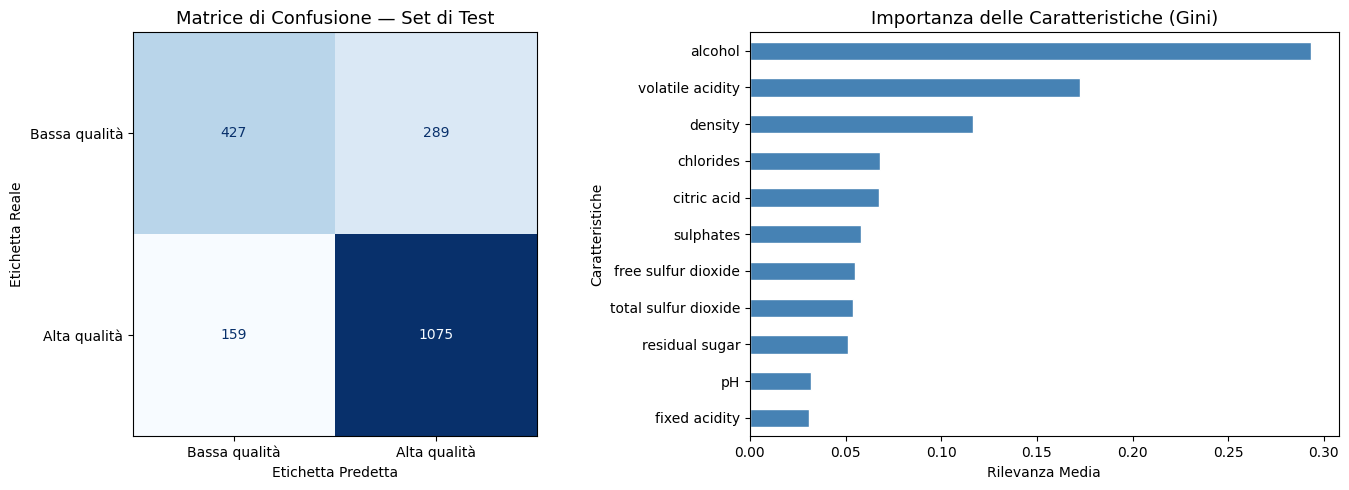


           ANALISI DELLE PRESTAZIONI DEL MODELLO            

 Report di Classificazione:
               precisione    richiamo  punteggio-f1   supporto

Bassa qualità       0.73      0.60      0.66       716
 Alta qualità       0.79      0.87      0.83      1234

     accuratezza                           0.77      1950
    media macro       0.76      0.73      0.74      1950
 media pesata       0.77      0.77      0.76      1950



In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_ts, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Bassa qualità', 'Alta qualità'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matrice di Confusione — Set di Test', fontsize=13)
axes[0].set_xlabel('Etichetta Predetta')
axes[0].set_ylabel('Etichetta Reale')

importances = pd.Series(clf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', ax=axes[1],
                                color='steelblue', edgecolor='white')
axes[1].set_title('Importanza delle Caratteristiche (Gini)', fontsize=13)
axes[1].set_xlabel('Rilevanza Media')
axes[1].set_ylabel('Caratteristiche')

plt.tight_layout()
plt.show()
plt.close()

print("\n" + "="*60)
print(" ANALISI DELLE PRESTAZIONI DEL MODELLO ".center(60, " "))

report = classification_report(y_ts, y_pred,
                               target_names=['Bassa qualità', 'Alta qualità'])

print('\n Report di Classificazione:')
print(report.replace('precision', 'precisione')
            .replace('recall', 'richiamo')
            .replace('f1-score', 'punteggio-f1')
            .replace('support', 'supporto')
            .replace('accuracy', 'accuratezza')
            .replace('macro avg', 'media macro')
            .replace('weighted avg', 'media pesata'))



### Visualizza uno degli Alberi Piccoli della Foresta

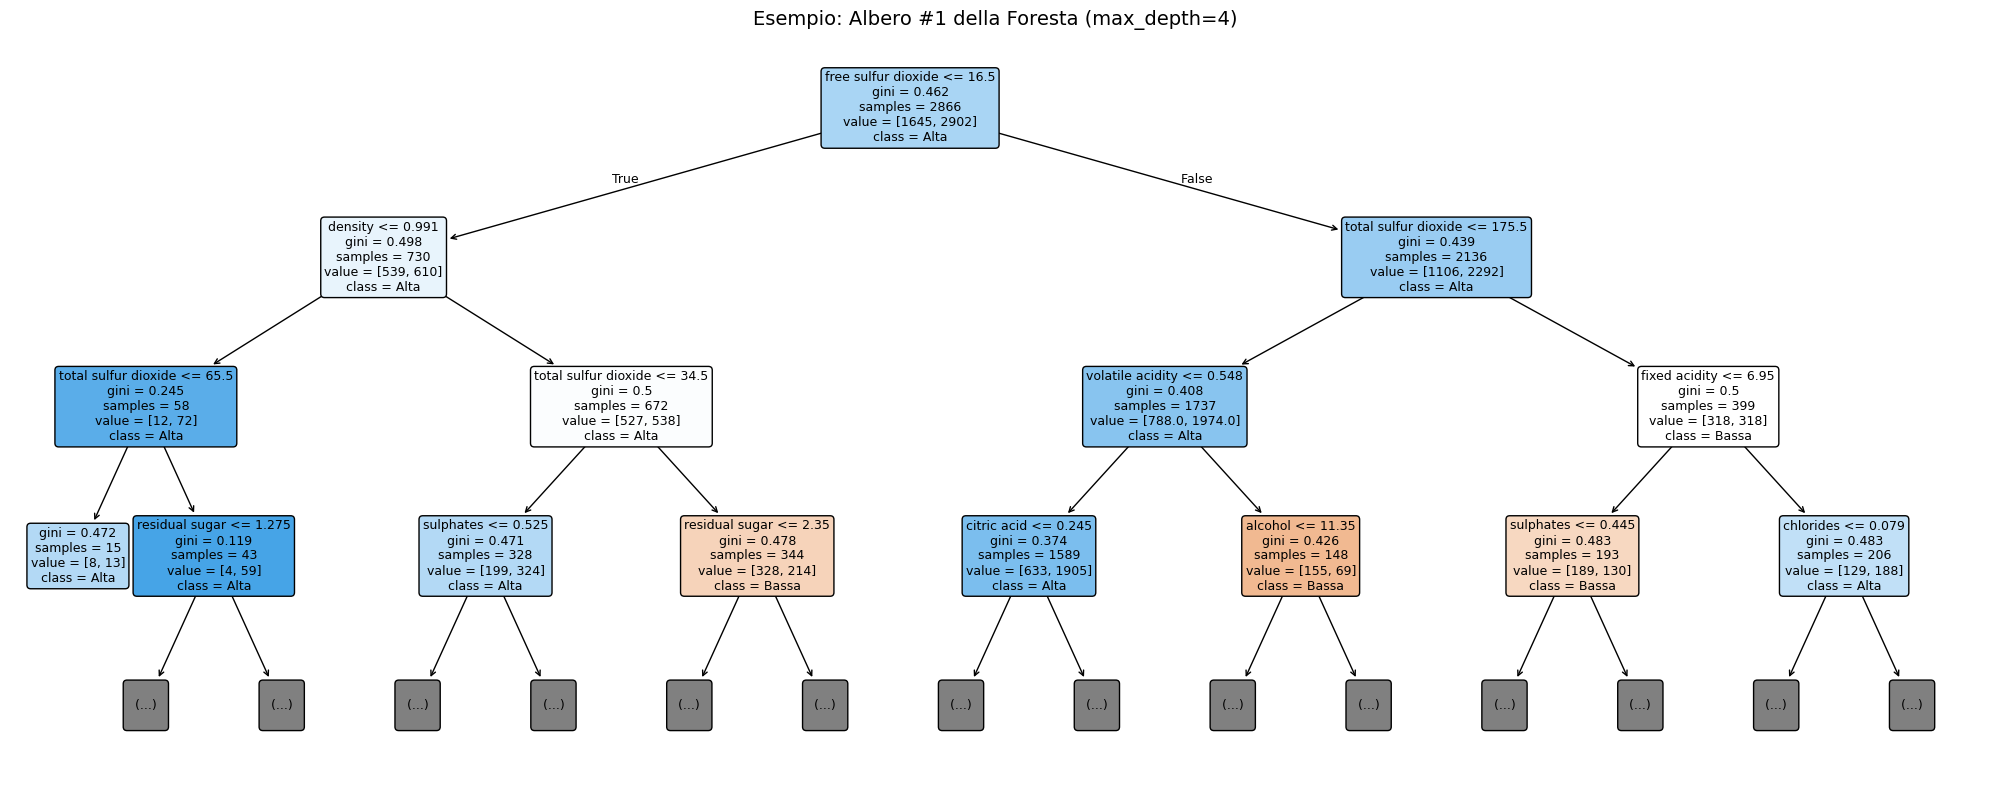

In [ ]:
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    clf.estimators_[0],
    feature_names=X.columns,
    class_names=['Bassa', 'Alta'],
    filled=True,
    rounded=True,
    max_depth=3,
    ax=ax,
    fontsize=9
)
ax.set_title('Esempio: Albero #1 della Foresta (max_depth=4)', fontsize=14)
plt.tight_layout()
plt.show()
